In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

### Data Preprocessing:
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [2]:
df=pd.read_csv('EastWestAirlines.csv')

In [3]:
df.shape

(3999, 12)

In [4]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [5]:

# Drop ID column
df = df.drop(columns=['ID#'])

# Check missing values
print(df.isnull().sum())

# Handle missing values (if any)
df = df.fillna(df.median(numeric_only=True))

# Convert categorical (cc miles) to numeric
cols = ['cc1_miles','cc2_miles','cc3_miles']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Outlier removal using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


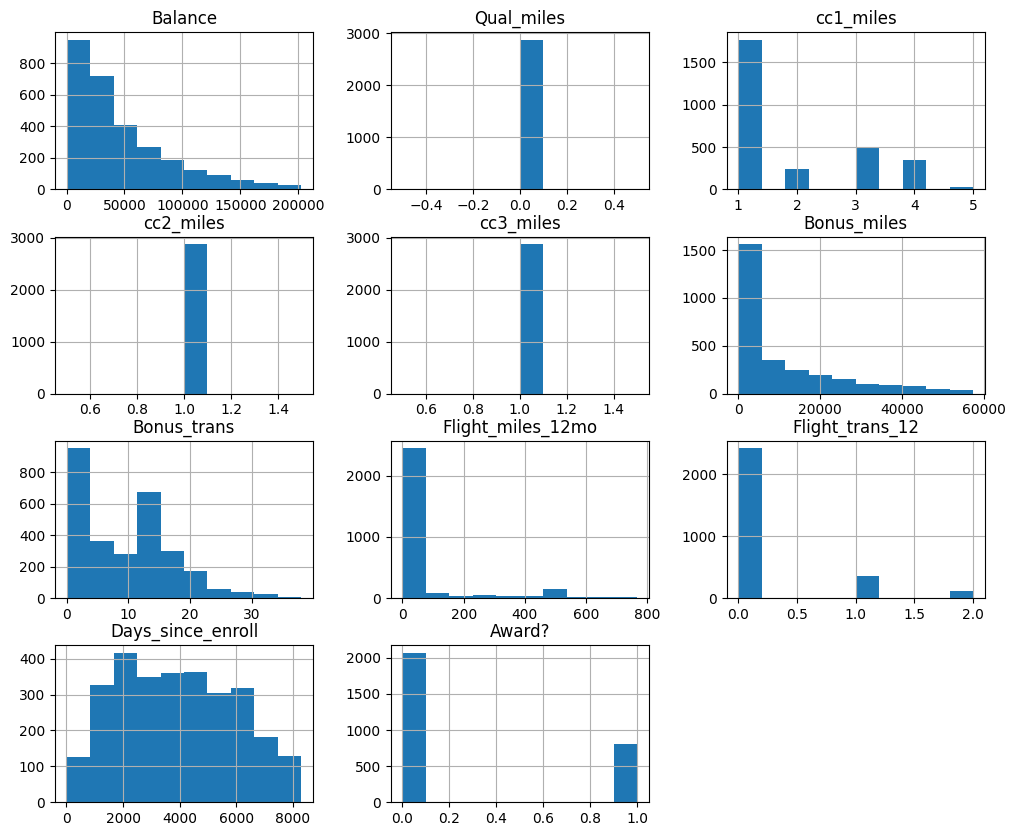

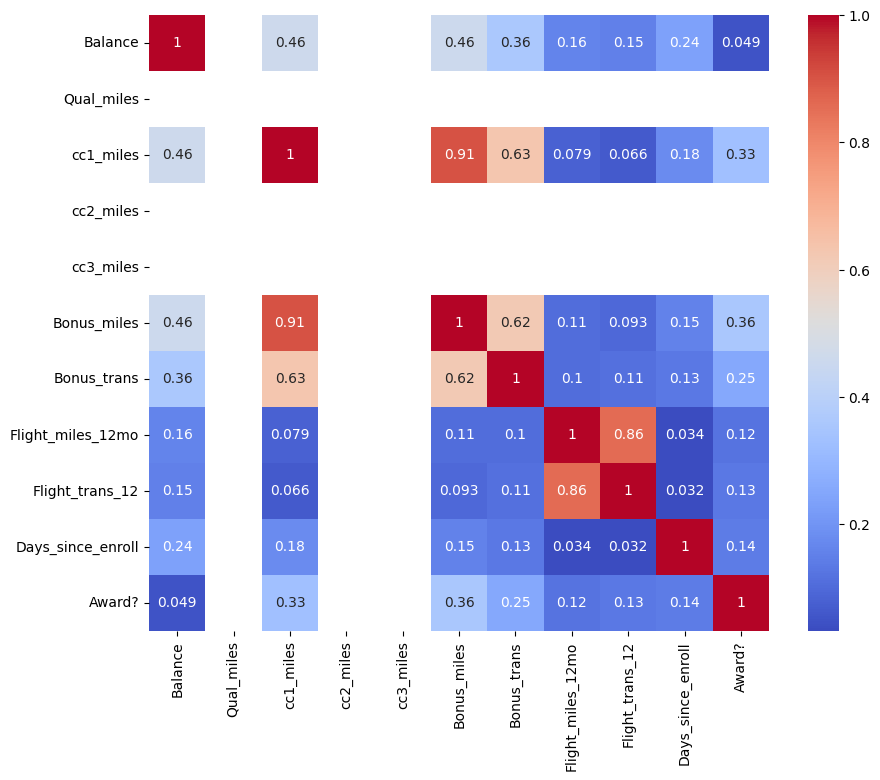

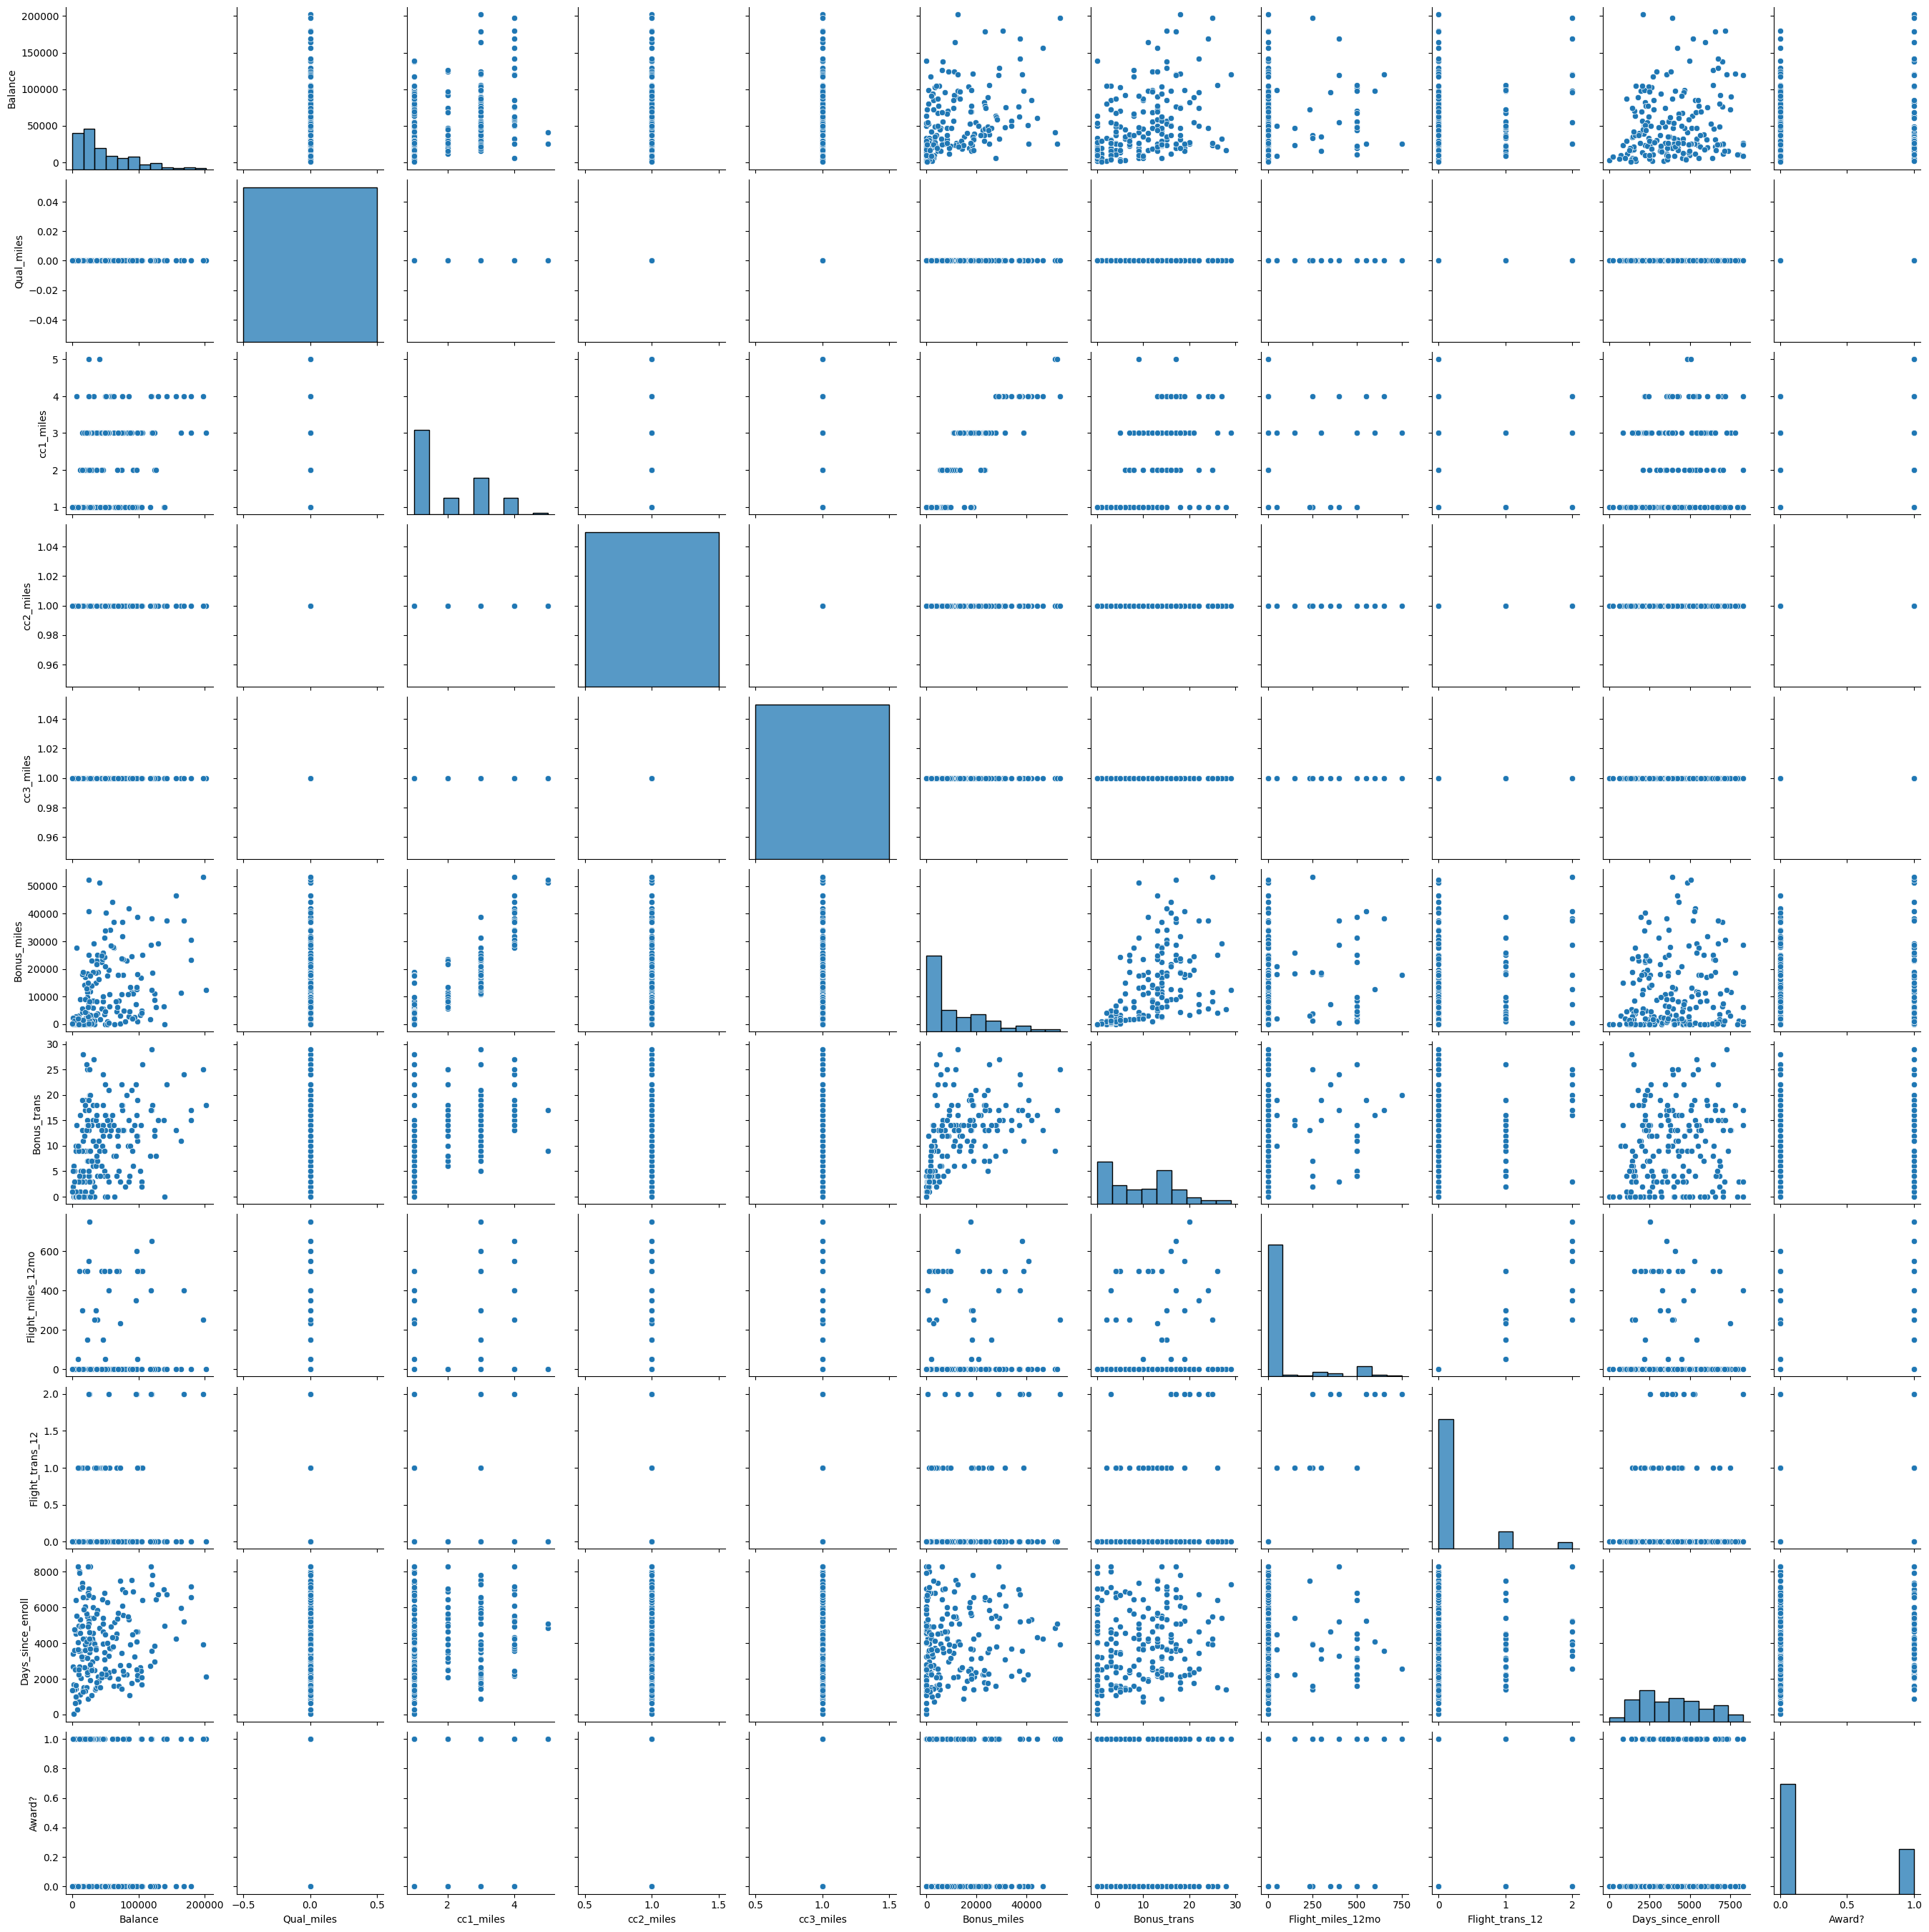

In [6]:
# Distribution
df.hist(figsize=(12,10))
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Pairplot (sample)
sns.pairplot(df.sample(200))
plt.show()

### Implementing Clustering Algorithms:
•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.



### Elbow

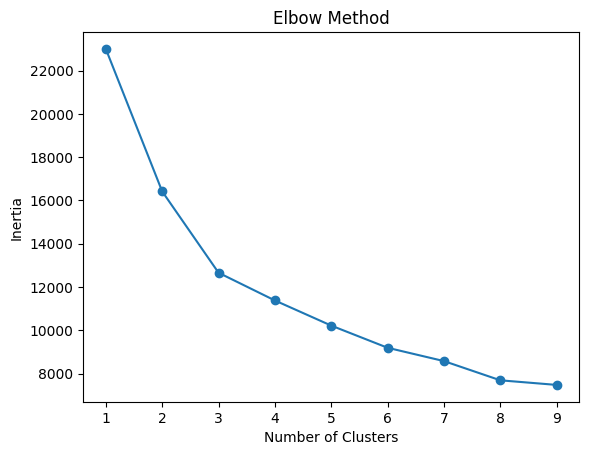

In [7]:
from sklearn.cluster import KMeans

inertia = []
K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

df['KMeans_Cluster'] = kmeans_labels

In [12]:
eps= [0.07,0.1,0.2,0.3,0.4,0.5,0.6,0.8,1.0,1.2,1.5,1.8,2.0]
min_nodes= range(1,16)
output=[]
for i in eps:
    for j in min_nodes:
        label= DBSCAN(eps=i,min_samples=j).fit(scaled_data).labels_
        score= silhouette_score(scaled_data,label)
        output.append([i,j,score])
print(output)

[[0.07, 1, np.float64(0.0445541647631652)], [0.07, 2, np.float64(-0.36461978231955783)], [0.07, 3, np.float64(-0.26110771789218606)], [0.07, 4, np.float64(-0.28424394345300613)], [0.07, 5, np.float64(-0.26456316428688226)], [0.07, 6, np.float64(-0.2616119319712133)], [0.07, 7, np.float64(-0.17838242634332754)], [0.07, 8, np.float64(-0.16592517802786078)], [0.07, 9, np.float64(-0.09088183424162585)], [0.07, 10, np.float64(-0.07400139350998652)], [0.07, 11, np.float64(-0.07327390863710982)], [0.07, 12, np.float64(-0.07360214981546624)], [0.07, 13, np.float64(-0.07360214981546624)], [0.07, 14, np.float64(-0.07375198908956715)], [0.07, 15, np.float64(-0.07375198908956715)], [0.1, 1, np.float64(0.011575769906340004)], [0.1, 2, np.float64(-0.38421700598410985)], [0.1, 3, np.float64(-0.27382049119153684)], [0.1, 4, np.float64(-0.2601722888582782)], [0.1, 5, np.float64(-0.25486479504113635)], [0.1, 6, np.float64(-0.23607987257327517)], [0.1, 7, np.float64(-0.24723170827324825)], [0.1, 8, np.fl

In [13]:
eps,min_node, score=sorted(output,reverse=True,key=lambda x: x[2])[0]
print('eps:',eps,',','min_samples:',min_node,',','score:',score)

eps: 2.0 , min_samples: 3 , score: 0.26527136570349785


In [9]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

df['DBSCAN_Cluster'] = dbscan_labels

### Visualization:
Visualize the clustering results using scatter plots or other suitable visualization techniques.
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.


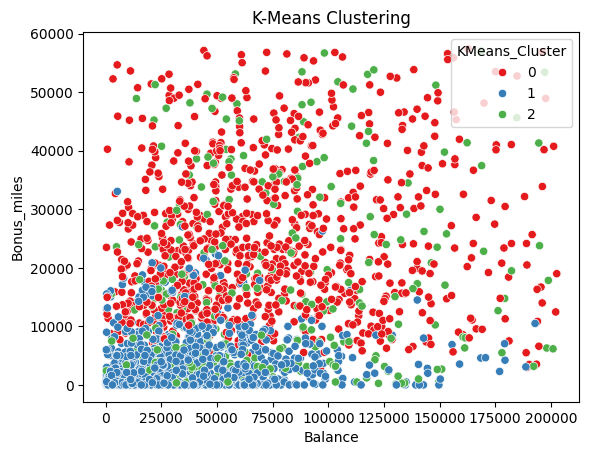

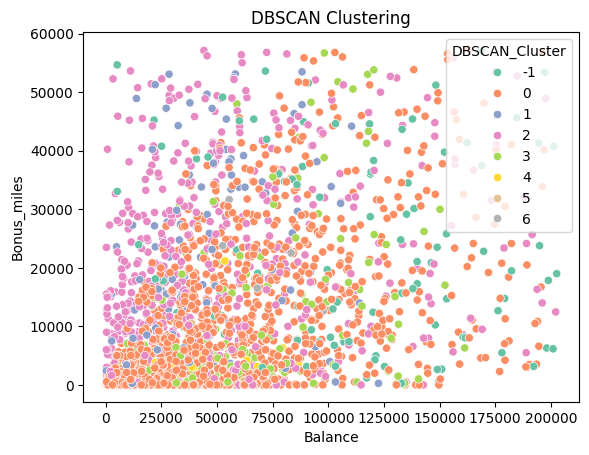

In [10]:
# Example scatter plot
sns.scatterplot(
    x=df['Balance'],
    y=df['Bonus_miles'],
    hue=df['KMeans_Cluster'],
    palette='Set1'
)
plt.title("K-Means Clustering")
plt.show()


sns.scatterplot(
    x=df['Balance'],
    y=df['Bonus_miles'],
    hue=df['DBSCAN_Cluster'],
    palette='Set2'
)
plt.title("DBSCAN Clustering")
plt.show()

### Cluster Analysis and Interpretation:
•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


### Evaluation and Performance Metrics:
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [14]:
from sklearn.metrics import silhouette_score

# K-Means score
kmeans_score = silhouette_score(scaled_data, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_score)

# DBSCAN score (ignore noise = -1)
mask = dbscan_labels != -1
dbscan_score = silhouette_score(scaled_data[mask], dbscan_labels[mask])
print("DBSCAN Silhouette Score:", dbscan_score)

K-Means Silhouette Score: 0.34184773367504273
DBSCAN Silhouette Score: 0.2673349072078038
